In [1]:
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pickle
import numpy as np
import tensorflow as tf
import pandas as pd
from IPython.display import FileLink

ALL_MODELS = {
    'GRU64': "model_GRU64_gradclip_RedPl",
    'LSTM64': "model_LSTM64_gradclip_RedPl",
    'LSTM32x2': "model_LSTM32x2_gradclip_RedPl_seq336_B128",
    'GRU32x2': "model_GRU32x2_gradclip_RedPl_seq336_B128",
    'LSTM64_1h': "model_1Hour_LSTM64_gradclip_RedPl_seq336",
    'GRU64_1h': "model_1Hour_GRU64_gradclip_RedPl_seq336",
    'LSTM32x2_1h': "model_1Hour_LSTM32x2_gradclip_RedPl_seq336_B128",
    'GRU32x2_1h': "model_1Hour_GRU32x2_gradclip_RedPl_seq336_B128"
}


2025-08-19 19:11:06.350274: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755630666.676012      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755630666.775282      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
#code to locate the working directory and list available files

print("Current working directory:", os.getcwd())

input_dir = '/kaggle/input/'

for root, dirs, files in os.walk(input_dir):
    print(f"Directory: {root}")
    print('---')




Current working directory: /kaggle/working
Directory: /kaggle/input/
---
Directory: /kaggle/input/energy-production
---
Directory: /kaggle/input/lstm-models
---
Directory: /kaggle/input/lstm-models/model_1Hour_GRU32x2_gradclip_RedPl_seq336_B128
---
Directory: /kaggle/input/lstm-models/model_LSTM64_gradclip_RedPl
---
Directory: /kaggle/input/lstm-models/model_1Hour_LSTM64_gradclip_RedPl_seq336
---
Directory: /kaggle/input/lstm-models/model_LSTM32x2_gradclip_RedPl_seq336_B128
---
Directory: /kaggle/input/lstm-models/model_GRU32x2_gradclip_RedPl_seq336_B128
---
Directory: /kaggle/input/lstm-models/model_1Hour_GRU64_gradclip_RedPl_seq336
---
Directory: /kaggle/input/lstm-models/model_GRU64_gradclip_RedPl
---
Directory: /kaggle/input/lstm-models/model_1Hour_LSTM32x2_gradclip_RedPl_seq336_B128
---


## Definitions

In [3]:
def make_history_path(model, base="/kaggle/input/lstm-models/", reg=ALL_MODELS):
    return f"{base}{reg[model]}/{reg[model]}_history.pkl"

def load_hist(path):
    if not os.path.exists(path):
        print(f" missing: {path}")
        return None
    with open(path, "rb") as f:
        return pickle.load(f)


def plot_lstm_gru_comparison(models, config,
                             color_lstm="#8C000F", color_gru="#008080"):
    # Load history data
    paths      = [make_history_path(m) for m in models]
    histories  = [load_hist(p) for p in paths]
    if any(h is None for h in histories):
        raise SystemExit("missing history file(s)")

    epochs = [range(1, len(h["loss"]) + 1) for h in histories]

    # Build pairs: always LSTM (even index) vs GRU (odd index)
    pairs = [(i, i+1) for i in range(0, len(models), 2)]

    # Determine row-wise y-axis limits
    row_limits = {}
    for row in range(config["rows"]):
        row_pairs = pairs[row * config["cols"]:(row + 1) * config["cols"]]
        row_vals = []
        for l_idx, g_idx in row_pairs:
            row_vals.extend(histories[l_idx]["val_mae"])
            row_vals.extend(histories[g_idx]["val_mae"])
        y_min, y_max = min(row_vals), max(row_vals)
        margin = 0.05 * (y_max - y_min)
        row_limits[row] = (y_min - margin, y_max + margin)

    # Plot
    plt.figure(figsize=(config["cols"]*8, config["rows"]*6))
    for i, (l_idx, g_idx) in enumerate(pairs):
        row = i // config["cols"]
        plt.subplot(config["rows"], config["cols"], i + 1)

        # LSTM
        val_l = histories[l_idx]["val_mae"]
        best_l = np.argmin(val_l) + 1
        plt.plot(epochs[l_idx], val_l, "-", color=color_lstm, lw=2,
                 label=f"{models[l_idx]} Validation Set")
        plt.axvline(best_l, color=color_lstm, ls="--")

        # GRU
        val_g = histories[g_idx]["val_mae"]
        best_g = np.argmin(val_g) + 1
        plt.plot(epochs[g_idx], val_g, "-", color=color_gru, lw=2,
                 label=f"{models[g_idx]} Validation Set")
        plt.axvline(best_g, color=color_gru, ls="--")

        plt.title(f"{models[l_idx]} vs {models[g_idx]} – MAE")
        plt.xlabel("Epoch")
        plt.ylabel("MAE", fontsize=14, fontweight="bold")
        plt.ylim(*row_limits[row])
        plt.legend(loc="upper right")

    # Main title from config
    title = config.get("title", "Comparison of LSTM and GRU models – MAE")
    plt.figtext(0.5, 0.98, title, ha="center", fontsize=20, weight="bold")

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(config["filename"], dpi=300, bbox_inches="tight")
    plt.show()
    display(FileLink(config["filename"]))

print("Functions loaded!")

Functions loaded!


# **Model Predictions**

## **Dataset Initialization**

In [4]:
#Data-Import

df = pd.read_csv("/kaggle/input/energy-production/Gesamterzeugung_hourly.csv", index_col='Datum', parse_dates=True)

# Normalization parameters from the original training
Power_train = df["Stromerzeugung Gesamt"]["2015-01-01 00:00:00":"2018-06-30 23:00:00"]
Power_valid = df["Stromerzeugung Gesamt"]["2018-07-01 00:00:00":"2018-12-31 23:00:00"]

mean = Power_train.mean()
std = Power_train.std()

# Create normalized datasets
Power_train_norm = (Power_train - mean) / std
Power_valid_norm = (Power_valid - mean) / std

datasets = [
    ("Power_train", Power_train),
    ("Power_valid", Power_valid),
    ("Power_train_norm", Power_train_norm),
    ("Power_valid_norm", Power_valid_norm),
]

print(f"{'Dataset':<20} {'Count':<8} {'Mean':<12} {'Std':<12} {'Min':<12} {'Max':<12}")
print("-" * 78)

# First 2 rows without decimal places
for i in range(2):
    name, data = datasets[i]
    desc = data.describe()
    print(f"{name:<20} {desc['count']:<8.0f} {desc['mean']:<12.0f} {desc['std']:<12.0f} {desc['min']:<12.0f} {desc['max']:<12.0f}")

print()

# Last 2 rows with decimal places
for i in range(2, 4):
    name, data = datasets[i]
    desc = data.describe()
    print(f"{name:<20} {desc['count']:<8.0f} {desc['mean']:<12.2f} {desc['std']:<12.2f} {desc['min']:<12.2f} {desc['max']:<12.2f}")


Dataset              Count    Mean         Std          Min          Max         
------------------------------------------------------------------------------
Power_train          30648    60689        9845         0            114548      
Power_valid          4416     61869        9447         38536        101353      

Power_train_norm     30648    0.00         1.00         -6.16        5.47        
Power_valid_norm     4416     0.12         0.96         -2.25        4.13        


## Definitions

In [5]:
def load_best_model(model_name, model_dir):
    
    history_path = f"{model_dir}{model_name}_history.pkl"
    
    with open(history_path, 'rb') as file:
        history = pickle.load(file)
    
    best_epoch = np.argmin(history['val_mae']) + 1
    model_path = f"{model_dir}{model_name}-epoch-{best_epoch:02d}.keras"
    model = tf.keras.models.load_model(model_path)
    
    print(f"{model_name}: Best epoch {best_epoch}")
    return model, best_epoch

def generate_predictions(model, base_offset, num_plots, num_predictions, iterative=False):
    
    all_data = []
    prediction_info = []
    
    for plot_idx in range(num_plots):
        plot_offset = base_offset + (plot_idx * 672)
        predictions, targets, time_indices, info = [], [], [], []
        
        for i in range(num_predictions):
            input_start = plot_offset + (i * 24)
            input_end = input_start + 336
            pred_start, pred_end = input_end, input_end + 24
            
            input_seq = Power_valid_norm.iloc[input_start:input_end].to_numpy()
            target_seq = Power_valid.iloc[pred_start:pred_end].to_numpy()
            
            if iterative:
                # Iterative 24h prediction
                day_predictions = []
                current_input = input_seq.copy()
                
                for hour in range(24):
                    model_input = current_input.reshape(1, 336, 1)
                    next_hour_norm = model.predict(model_input, verbose=0)[0, 0]
                    next_hour_real = (next_hour_norm * std) + mean
                    
                    day_predictions.append(next_hour_real)
                    current_input = np.roll(current_input, -1)
                    current_input[-1] = next_hour_norm
                
                prediction = day_predictions
            else:
                # Direct prediction for 24 hours
                prediction_norm = model.predict(input_seq.reshape(1, 336, 1), verbose=0)
                prediction = (prediction_norm[0] * std) + mean
            
            predictions.extend(prediction)
            targets.extend(target_seq)
            time_indices.extend(Power_valid.iloc[pred_start:pred_end].index)
            info.append(f"{i+1}/{num_predictions}|{input_start}-{input_end-1}|{pred_start}-{pred_end-1}")
        
        all_data.append({
            'predictions': predictions, 'targets': targets, 
            'time_indices': time_indices, 'offset_days': plot_idx * 28
        })
        prediction_info.append(info)
    
    return all_data, prediction_info



def create_prediction_plot(config, model_names, iterative=False):
  
    # Default plot styles defined directly in function
    DEFAULT_STYLES = {
        'real_graph': {'color': '#000000', 'linewidth': 3, 'linestyle': '-'},
        'lstm_graph': {'color': '#8C000F', 'linewidth': 3, 'linestyle': '--'},
        'gru_graph': {'color': '#008080', 'linewidth': 3, 'linestyle': '-.'}
    }
    
    offset_days = config.get('offset_days') or config.get('Offset_days') or config.get('Offset_Days', 59)
    
    input_start_base = offset_days * 24
    total_needed = input_start_base + ((config['num_plots'] - 1) * 672) + 336 + (config['num_predictions'] * 24)
    
    print(f"Offset: {offset_days} days | Predictions: {config['num_predictions']} × 24h | Plots: {config['num_plots']}")
    
    if total_needed > len(Power_valid_norm):
        print(f"ERROR: Not enough data! Required: {total_needed}, Available: {len(Power_valid_norm)}")
        return
    
    # Load models with automatic path generation
    loaded_models = {}
    for name in model_names:
        model_name = ALL_MODELS[name]
        model_path = f"/kaggle/input/lstm-models/{model_name}/"
        loaded_models[name], _ = load_best_model(model_name, model_path)
    
    # Generate predictions
    all_plot_data = {}
    prediction_info = {}
    for name, model in loaded_models.items():
        all_plot_data[name], prediction_info[name] = generate_predictions(
            model, input_start_base, config['num_plots'], config['num_predictions'], iterative=iterative
        )
    
    # Create plots
    fig, axes = plt.subplots(config['num_plots'], 1, 
                             figsize=(max(15, config['num_predictions'] * 4), config['num_plots'] * 8))
    if config['num_plots'] == 1:
        axes = [axes]
    
    for plot_idx, ax in enumerate(axes):
        for i, (name, data_list) in enumerate(all_plot_data.items()):
            data = data_list[plot_idx]
            
            # Plot real values only once
            if i == 0:
                real_style = config.get('real_graph', DEFAULT_STYLES['real_graph'])
                ax.plot(data['time_indices'], data['targets'], 
                        color=real_style['color'], linewidth=real_style['linewidth'], 
                        linestyle=real_style['linestyle'], label='Real Values')
            
            # Plot model predictions with appropriate style
            if 'LSTM' in name:
                style = config.get('lstm_graph', DEFAULT_STYLES['lstm_graph'])
            elif 'GRU' in name:
                style = config.get('gru_graph', DEFAULT_STYLES['gru_graph'])
            else:
                style = {'color': '#0000FF', 'linewidth': 3, 'linestyle': '--'}
            
            ax.plot(data['time_indices'], data['predictions'], 
                    color=style['color'], linewidth=style['linewidth'], 
                    linestyle=style['linestyle'], label=f'{name} Prediction')
        
        # Day separation lines
        for i in range(1, config['num_predictions']):
            boundary = data['time_indices'][i * 24]
            ax.axvline(boundary, color='gray', linestyle=':', alpha=0.7)
            ax.text(boundary, ax.get_ylim()[1] * 0.95, f'Day {i+1}', rotation=90, ha='right', fontweight='bold')
        
        # Formatting with correct title based on iterative parameter
        title_type = '1h iterative Prediction' if iterative else '24h Prediction'
        ax.set_title(f'{config["num_predictions"]}-Day Window - {title_type} - {config["title"]}', 
                     fontweight='bold', fontsize=18)
        ax.set_ylabel('Power Generation [MWh]', fontweight='bold', size=16)
        ax.legend(fontsize=14)
        
        # Date formatting for x-axis
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
        ax.tick_params(axis='x', rotation=45, labelsize=14)
    
    plt.tight_layout()
    
    # Save plot
    if config['save_plot']:
        save_path = f"/kaggle/working/{config['plot_filename']}"
        fig.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        
        print(f"\n Plot saved at: {save_path}")
        print(" Download link:")
        display(FileLink(save_path))
        
        file_size = os.path.getsize(save_path) / (1024 * 1024)  # MB
        print(f" File size: {file_size:.2f} MB")
    
    plt.show()

print("Functions loaded!")




Functions loaded!


#  **Visualizations**

##  1Layer<>64Neurons -24Hours

Offset: 15 days | Predictions: 5 × 24h | Plots: 1
model_GRU64_gradclip_RedPl: Best epoch 82
model_LSTM64_gradclip_RedPl: Best epoch 94


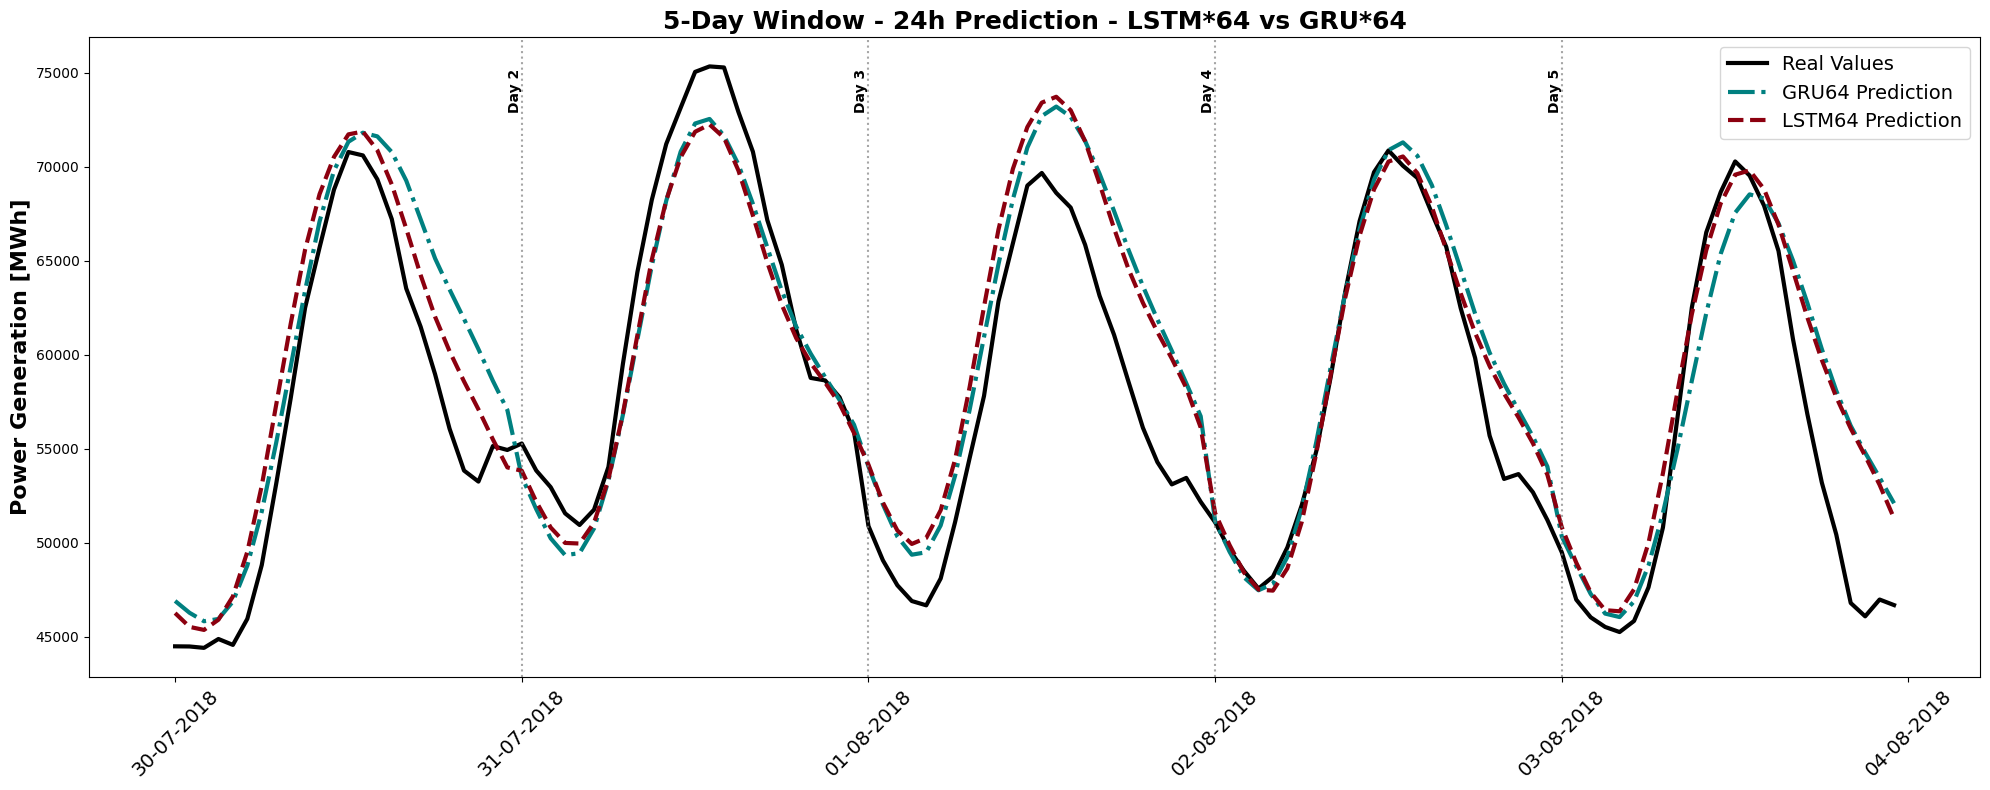

In [10]:
# = CONFIG 1 =
config1 = {
    'offset_days': 15,
    'num_predictions': 5,
    'num_plots': 1,
    'save_plot': False,
    'plot_filename': 'LSTM64_vs_GRU64_comparison_plot.png',
    'title': 'LSTM*64 vs GRU*64'
}
create_prediction_plot(config1, ['GRU64', 'LSTM64'], iterative=False)

# 2Layers<>32Neurons -24Hours

Offset: 15 days | Predictions: 5 × 24h | Plots: 1
model_LSTM32x2_gradclip_RedPl_seq336_B128: Best epoch 88
model_GRU32x2_gradclip_RedPl_seq336_B128: Best epoch 87


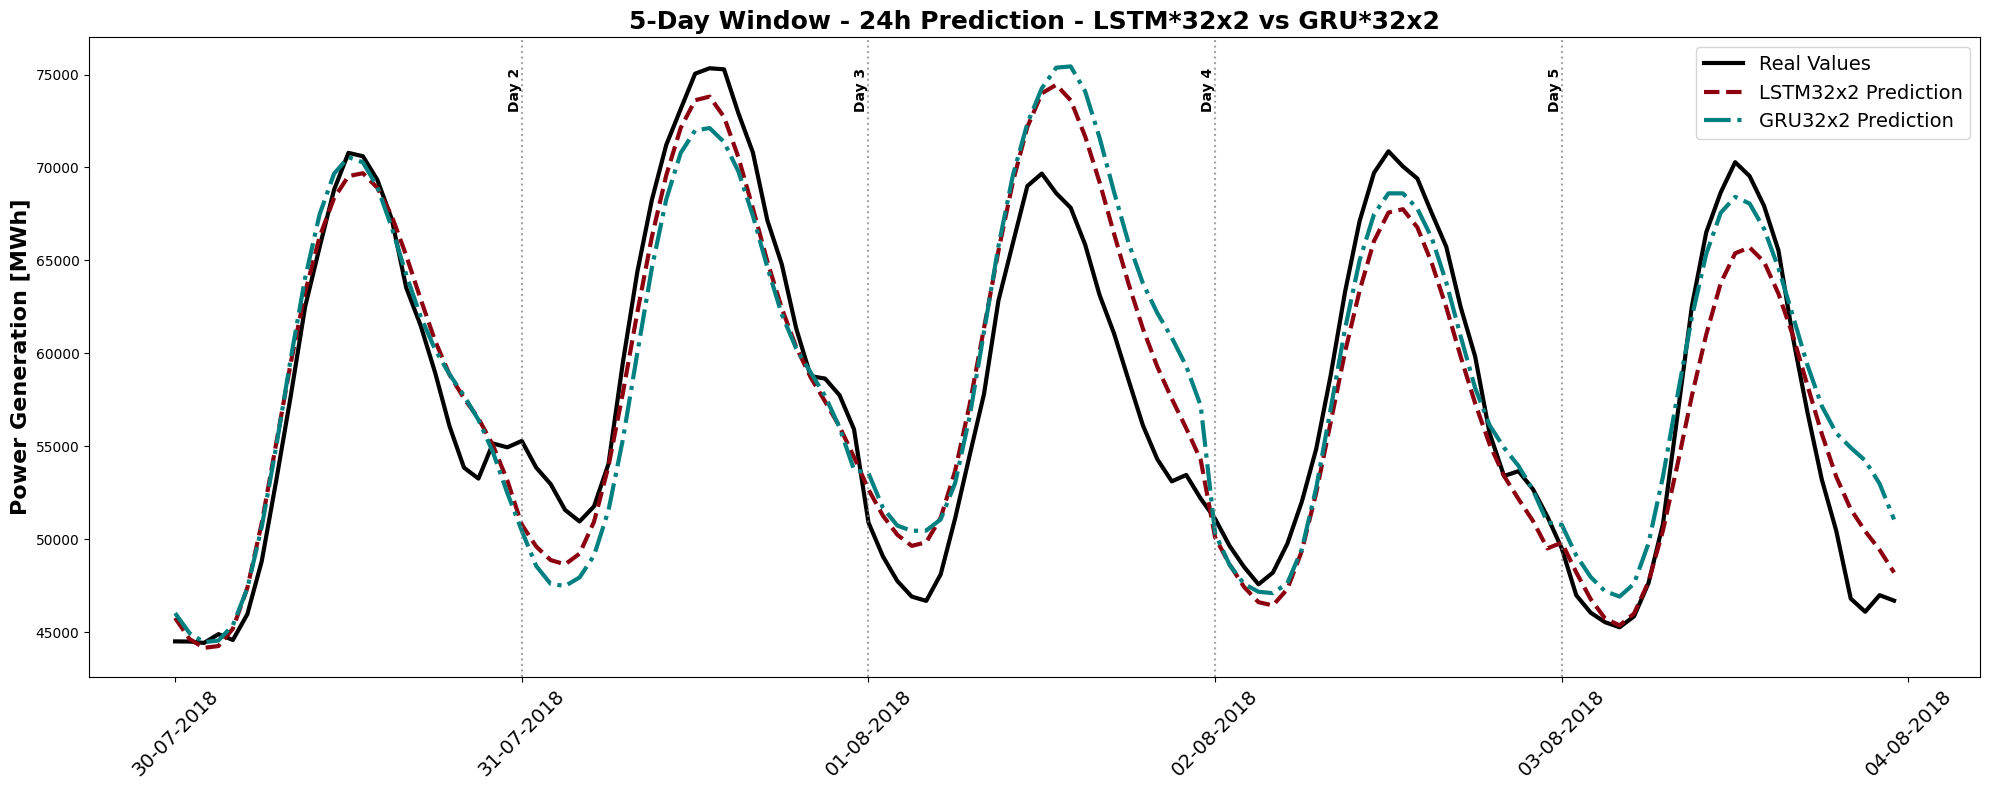

In [7]:
# = CONFIG 2 =
config2 = {
    'offset_days': 15,
    'num_predictions': 5,
    'num_plots': 1,
    'save_plot': False,
    'plot_filename': 'LSTM32x2_vs_GRU32x2_comparison_plot.png',
    'title': 'LSTM*32x2 vs GRU*32x2'
}
create_prediction_plot(config2, ['LSTM32x2', 'GRU32x2'], iterative=False)

# 1Layer<>64Neurons -1Hour

Offset: 15 days | Predictions: 5 × 24h | Plots: 1
model_1Hour_LSTM64_gradclip_RedPl_seq336: Best epoch 99
model_1Hour_GRU64_gradclip_RedPl_seq336: Best epoch 87


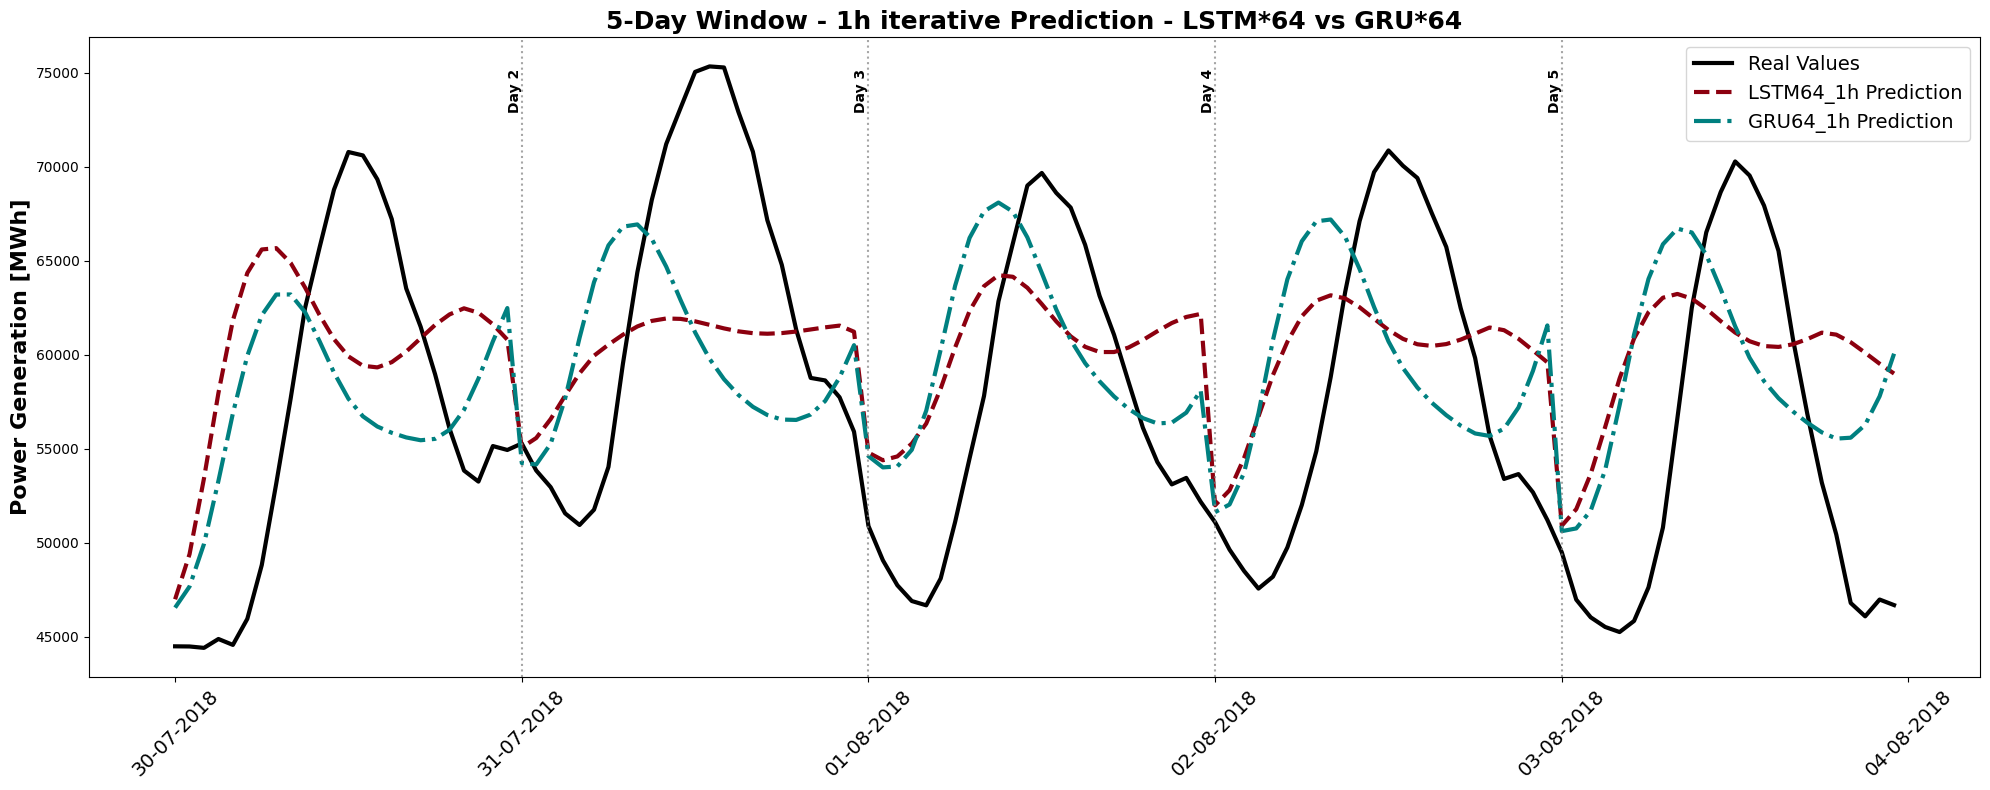

In [8]:
# = CONFIG 3 =
config3 = {
    'offset_days': 15,
    'num_predictions': 5,
    'num_plots': 1,
    'save_plot': False,
    'plot_filename': 'LSTM64_vs_GRU64_1hour_comparison.png',
    'title': 'LSTM*64 vs GRU*64'
}
create_prediction_plot(config3, ['LSTM64_1h', 'GRU64_1h'], iterative=True)


# 2Layers<>32Neurons -1Hour

Offset: 15 days | Predictions: 5 × 24h | Plots: 1
model_1Hour_LSTM32x2_gradclip_RedPl_seq336_B128: Best epoch 44
model_1Hour_GRU32x2_gradclip_RedPl_seq336_B128: Best epoch 43


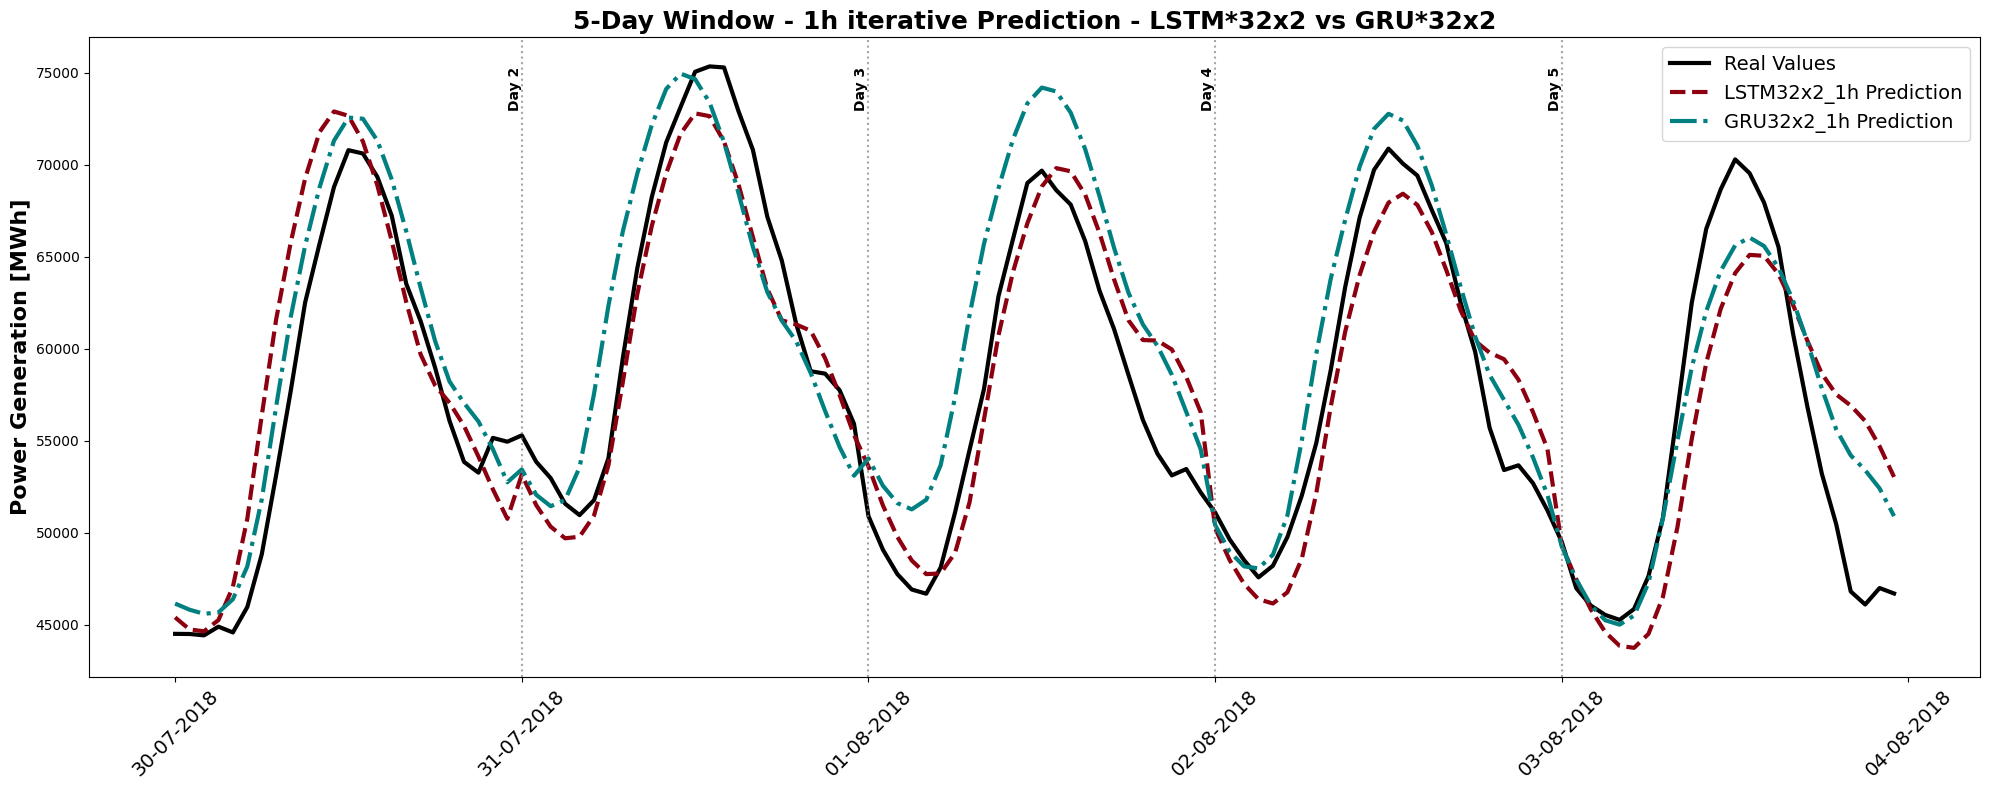

In [9]:
# = CONFIG 4 =
config4 = {
    'offset_days': 15,
    'num_predictions': 5,
    'num_plots': 1,
    'save_plot': False,
    'plot_filename': 'LSTM32x2_vs_GRU32x2_1hour_comparison.png',
    'title': 'LSTM*32x2 vs GRU*32x2'
}
create_prediction_plot(config4, ['LSTM32x2_1h', 'GRU32x2_1h'], iterative=True)